#**0. Preparation**

In [ ]:
# Packages and data
import os, zipfile # Unzip the zip file within online ipynb platform

rocks_zip = '/kaggle/input/hw03-q1/360 Rocks/360 Rocks.zip'

# Unzipping
if os.path.exists(rocks_zip):
    extract_to = os.path.splitext(rocks_zip)[0]

    with zipfile.ZipFile(rocks_zip, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    os.remove(rocks_zip)

else:
    print('File already extracted')

File already extracted


In [ ]:
# Necessary installations
!pip show tensorflow
!pip install umap-learn

Name: tensorflow
Version: 2.18.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras


In [ ]:
# Data extraction
import tensorflow as tf
import glob

image_path = glob.glob('/kaggle/input/360 Rocks/360 Rocks/*.jpg')
# Reshaped to 100*100*3
images = [tf.keras.preprocessing.image.load_img(p, target_size=(100, 100)) for p in image_path]

In [ ]:
import numpy as np
# Image tensors
image_tensor = tf.convert_to_tensor(np.array(images), dtype=tf.float32)

In [ ]:
image_tensor.shape

TensorShape([360, 100, 100, 3])

In [ ]:
# Flatten
flat_images = image_tensor.numpy().reshape(image_tensor.shape[0], -1)
flat_images.shape

(360, 30000)

#**1. PCA**

In [ ]:
from sklearn.decomposition import PCA

pca_model = PCA()
pca_model.fit(flat_images)

variances = np.cumsum(pca_model.explained_variance_ratio_)

var_95_components = np.argmax(variances >= 0.95) + 1

print(f'{var_95_components} components are required for 95% variance.')

227 components are required for 95% variance.


227 components are required for 95% variance.

#**2. Image plotting**

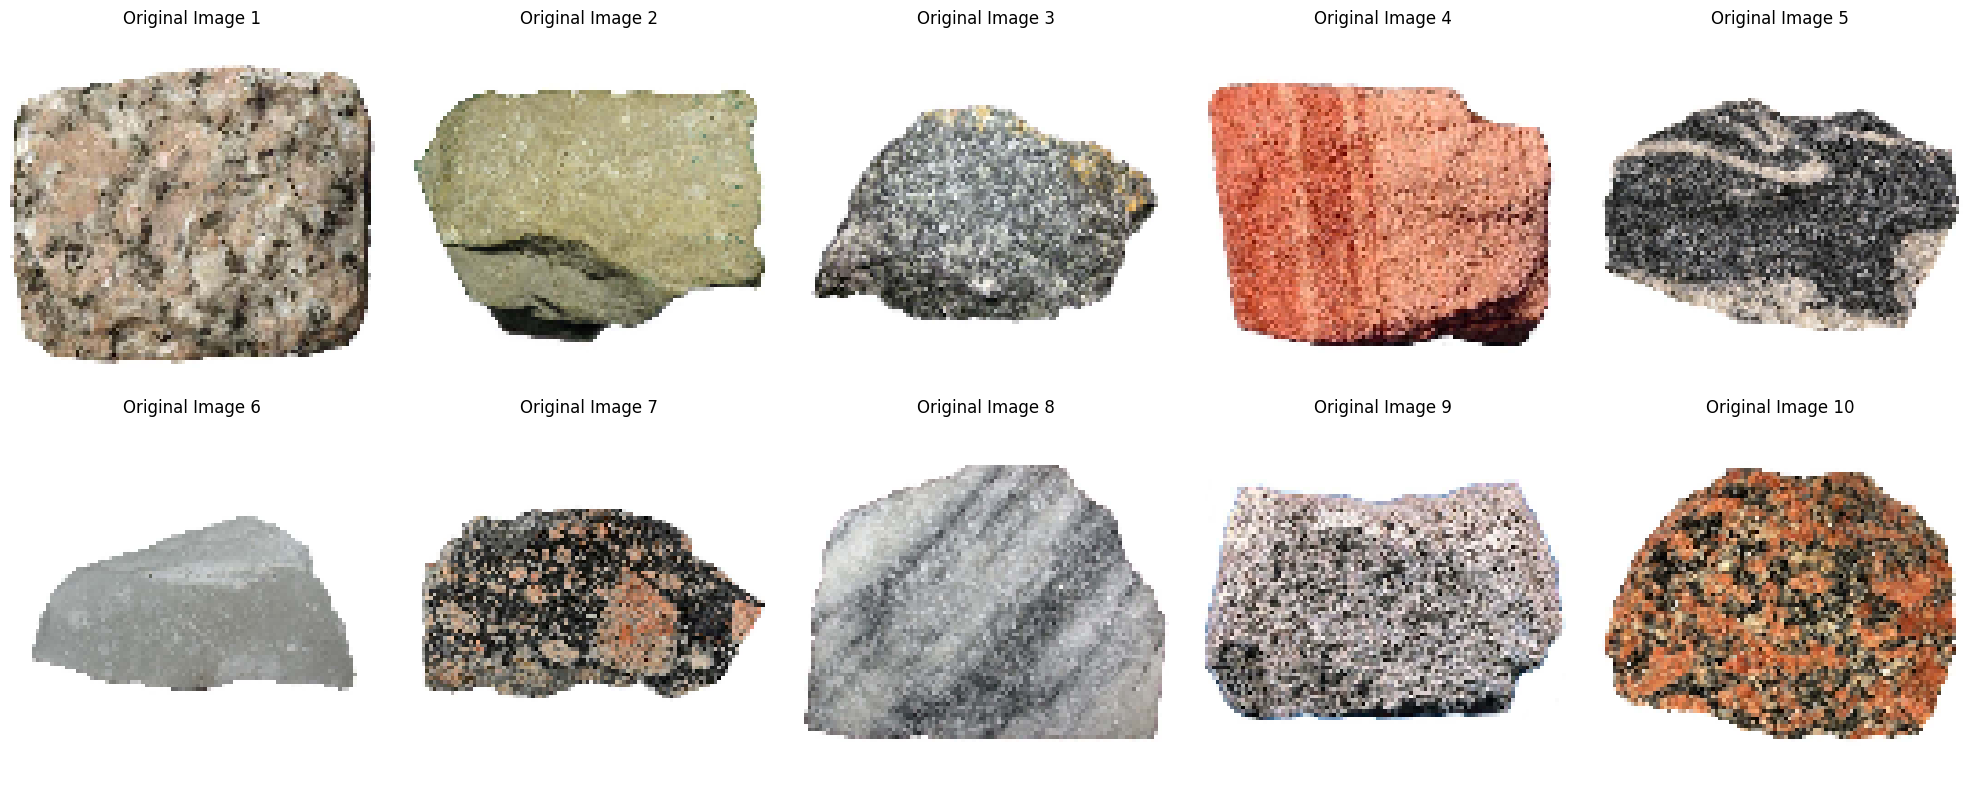

In [ ]:
import matplotlib.pyplot as plt
# Original form
selected_images = []

for i in range(10):
    selected_images.append(image_tensor[i*36])

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axs.flat):
    ax.imshow(selected_images[i].numpy().astype(np.uint8))
    ax.axis('off')
    ax.set_title(f"Original Image {i + 1}")
plt.tight_layout()
plt.show()

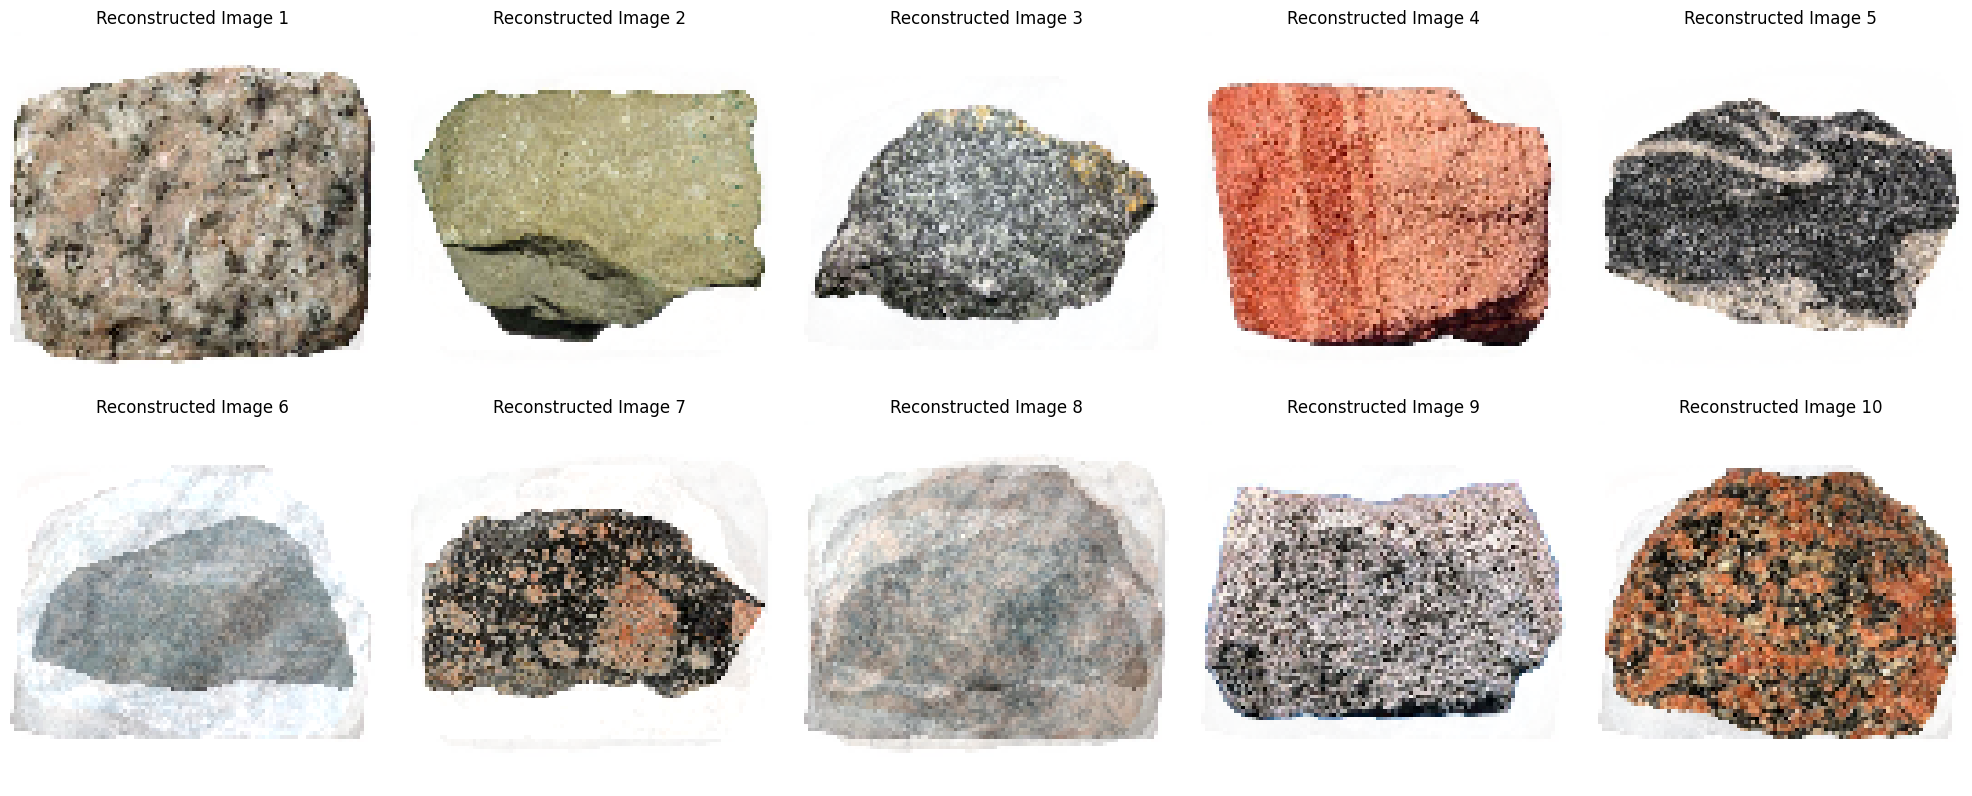

In [ ]:
# After PCA
pca = PCA(n_components=0.95)
selected_images = tf.convert_to_tensor(selected_images)
selected_images_flat = selected_images.numpy().reshape(selected_images.shape[0], -1)
selected_images_reduced = pca.fit_transform(selected_images_flat)

selected_images_reconstructed = pca.inverse_transform(selected_images_reduced)

reconstructed = selected_images_reconstructed.reshape(selected_images.shape)
reconstructed = np.clip(reconstructed, 0, 255)

fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, ax in enumerate(axs.flat):
    ax.imshow(reconstructed[i].astype(np.uint8))
    ax.axis('off')
    ax.set_title(f"Reconstructed Image {i + 1}")
plt.tight_layout()
plt.show()

#**3. Different clusters**

###A.

In [ ]:
image_tensor_labels = []
X = []

for path in image_path:
    img = tf.keras.preprocessing.image.load_img(path)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32) / 255.0

    X.append(img_tensor)

    filename = os.path.basename(path)
    label = filename[0]
    image_tensor_labels.append(label)


In [ ]:
X = tf.convert_to_tensor(np.array(X), dtype=tf.float32)
X_flat = image_tensor.numpy().reshape(X.shape[0], -1)
pca_2d = PCA(n_components=2)
pca_2d.fit(X_flat)

print(sum(pca_2d.explained_variance_ratio_))

0.322204165160656


First 2 dimensions explain 32.22% of the variance.

###B.

Here, we used dimension reduction (DR) method to reduce the dimensions, and then plot them with category labels and image thumbnails as labels, respectively. The DR methods are: PCA, t-SNE, LLE, UMAP.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_reduced = pca_2d.transform(X_flat)
X_reduced.shape

(360, 2)

In [ ]:
PC1 = X_reduced[:, 0]
PC2 = X_reduced[:, 1]
PC1, PC2 = np.array(PC1), np.array(PC2)

image_tensor_labels = np.array(image_tensor_labels)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

def plot_digits(X, y, min_distance=0.05, images=None, figsize=(12, 8)):
    if X.shape[0] != len(y):
        X = X.T
    X_normalized = MinMaxScaler().fit_transform(X)


    labels = np.unique(y)
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    n_labels = len(labels)
    numeric_y = np.array([label_to_index[label] for label in y])

    neighbors = np.array([[10., 10.]])
    plt.figure(figsize=figsize)
    cmap = plt.cm.jet
    ax = plt.gca()

    for label in labels:
        idx = label_to_index[label]
        plt.scatter(X_normalized[y == label, 0],
                    X_normalized[y == label, 1],
                    c=[cmap(idx / n_labels)],
                    label=label)

    plt.axis('off')

    for index, image_coord in enumerate(X_normalized):
        closest = np.linalg.norm(neighbors - image_coord, axis=1).min()
        if closest > min_distance:
            neighbors = np.r_[neighbors, [image_coord]]
            label_index = numeric_y[index]
            if images is None:
                plt.text(image_coord[0], image_coord[1], y[index],
                         color=cmap(label_index / len(labels)))

            else:
                image_size = int(np.sqrt(images.shape[1]))
                image = images[index]
                imagebox = AnnotationBbox(OffsetImage(image, cmap='binary', zoom=0.01), image_coord)
                ax.add_artist(imagebox)

    plt.show()

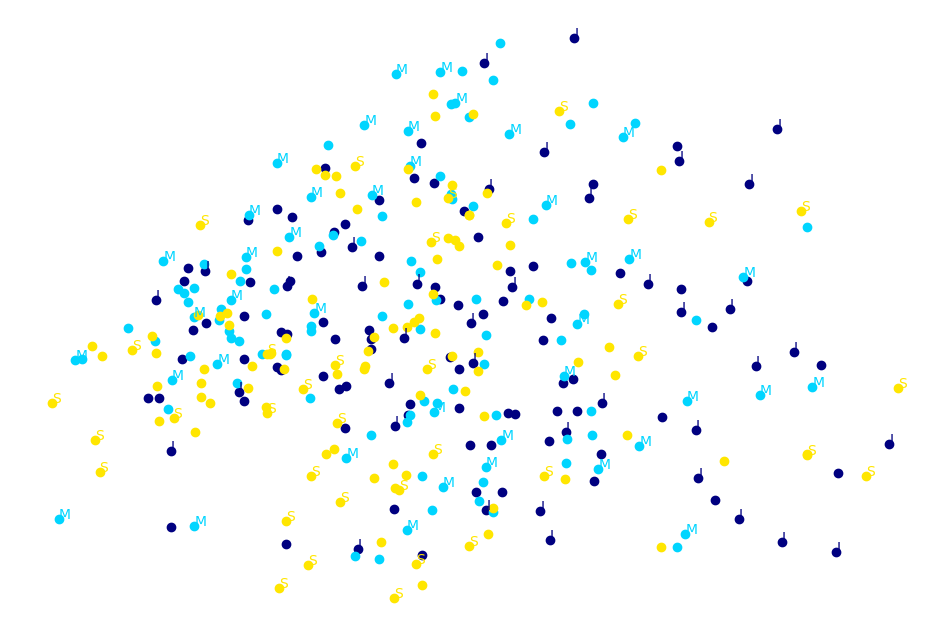

In [ ]:
plot_digits(np.array([PC1, PC2]).T, image_tensor_labels)

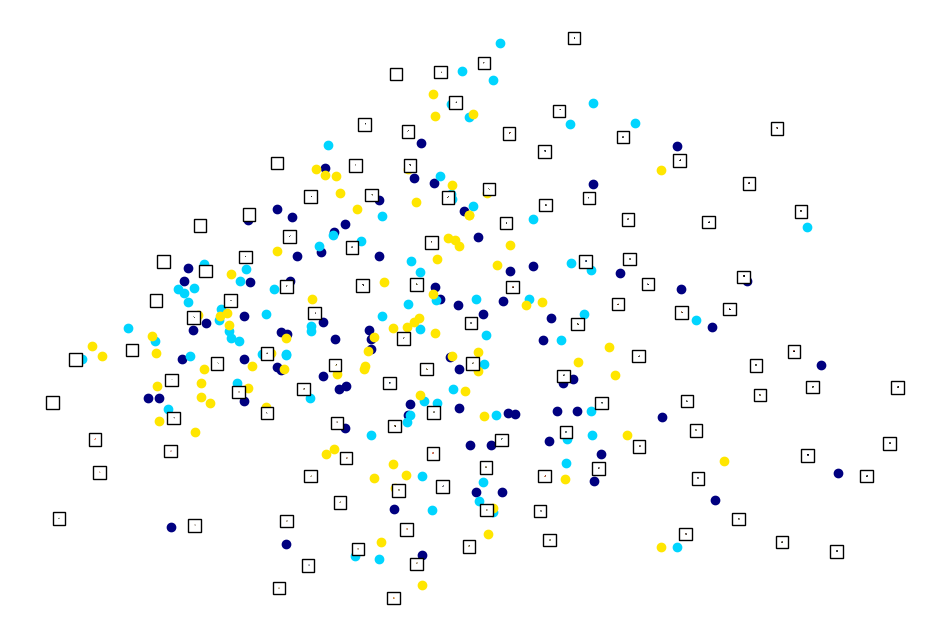

In [ ]:
images_np = np.array(images)
plot_digits(np.array([PC1, PC2]).T, image_tensor_labels, images=images_np)

In [ ]:
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from umap.umap_ import UMAP

In [ ]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_flat)

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

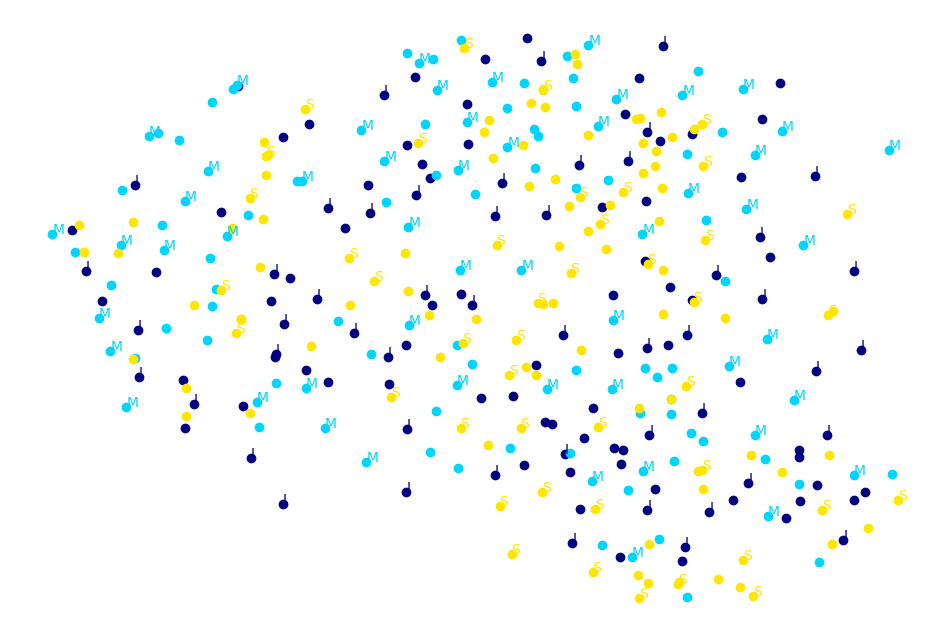

In [ ]:
plot_digits(X_tsne, image_tensor_labels)

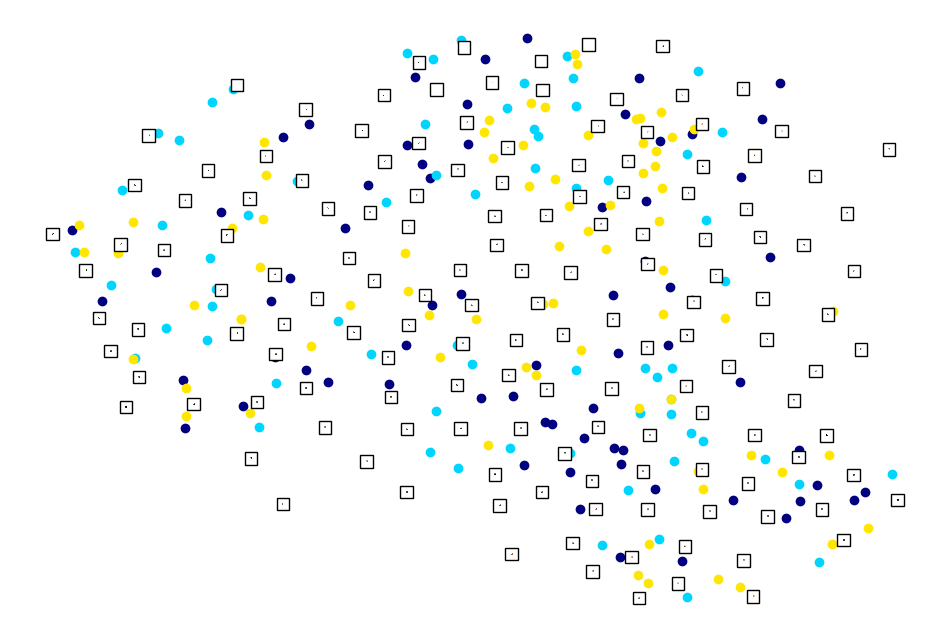

In [ ]:
plot_digits(X_tsne, image_tensor_labels, images=images_np)

In [ ]:
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=25, method='standard', random_state=42)
X_lle = lle.fit_transform(X_flat)

OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detect OpenMP Loop and this application may hang. Please rebuild the library with USE_OPENMP=1 option.
OpenBLAS Warning : Detec

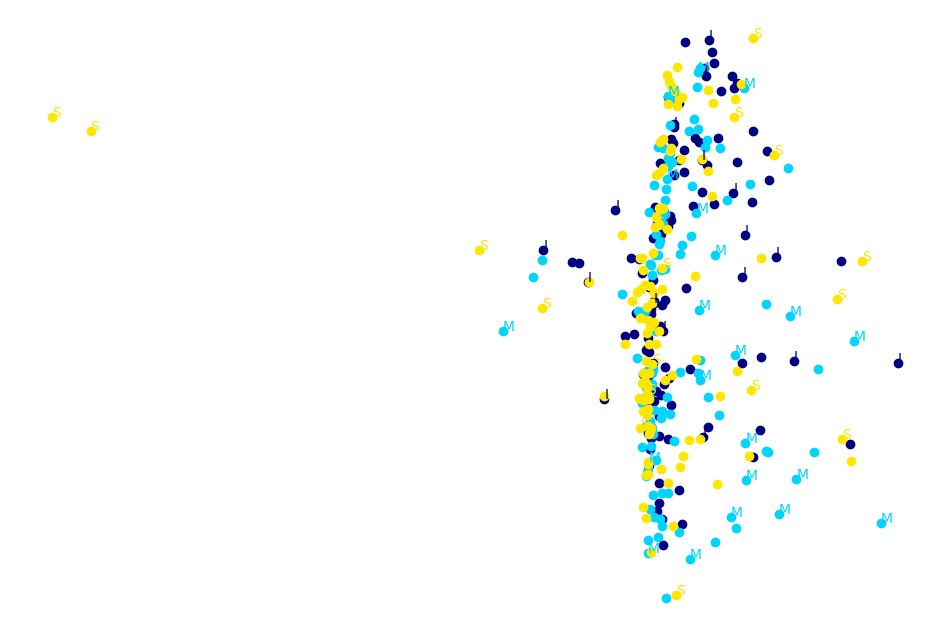

In [ ]:
plot_digits(X_lle, image_tensor_labels)

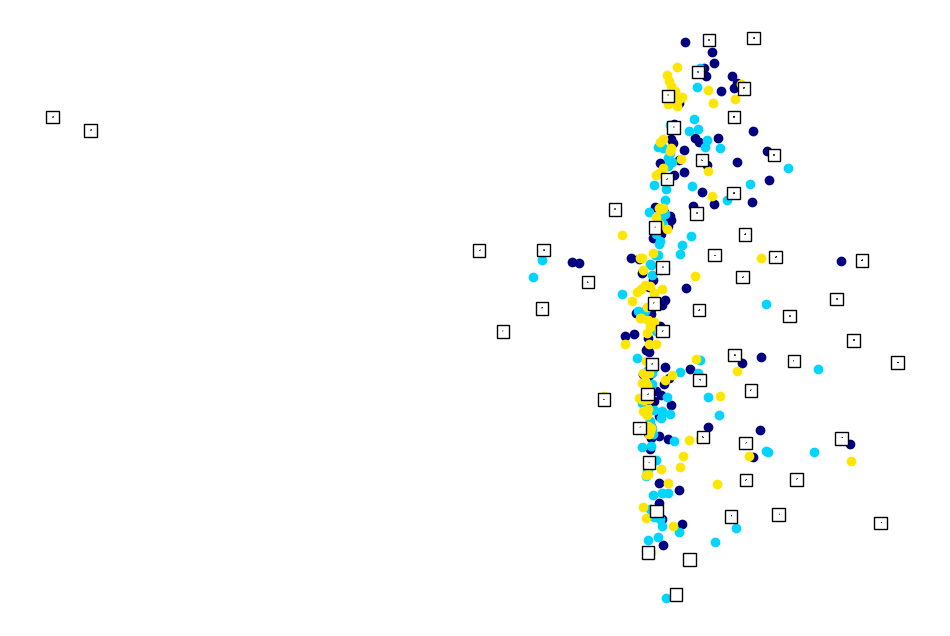

In [ ]:
plot_digits(X_lle, image_tensor_labels, images=images_np)

In [ ]:
UMAP = UMAP(n_components=2, random_state=42)
X_umap = UMAP.fit_transform(X_flat)

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


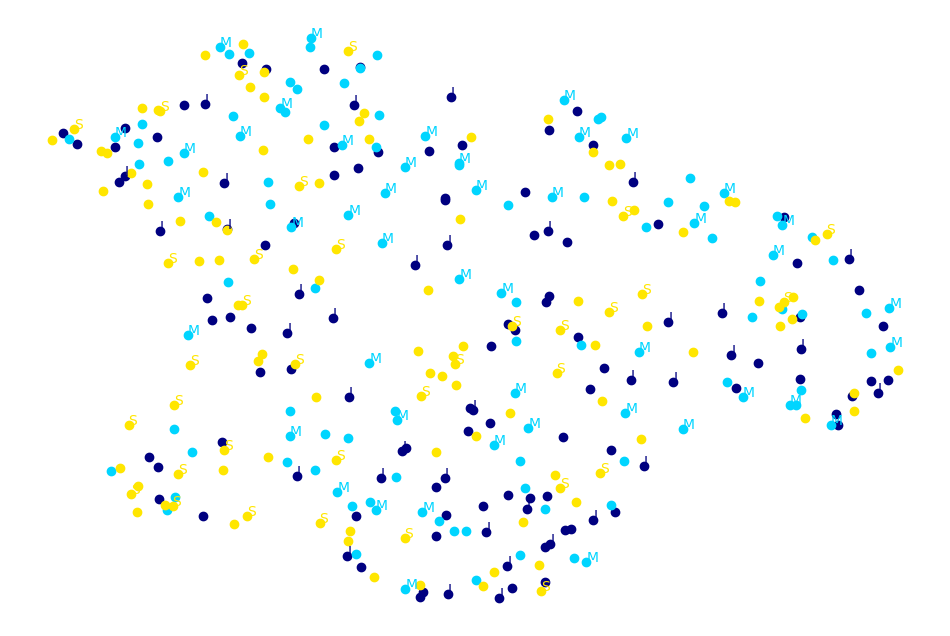

In [ ]:
plot_digits(X_umap, image_tensor_labels)

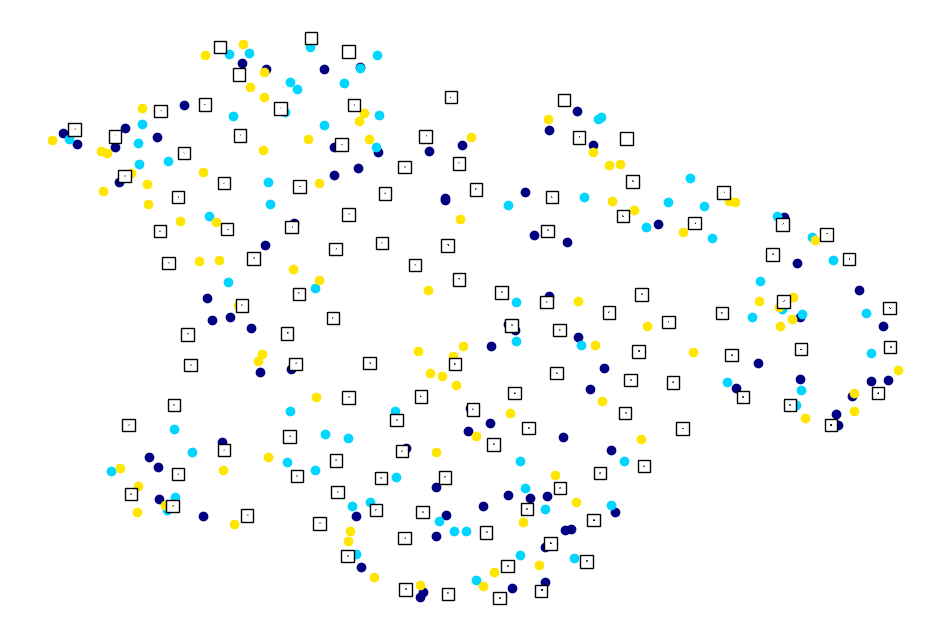

In [ ]:
plot_digits(X_umap, image_tensor_labels, images=images_np)

###C.

Though the whole dataset is scattered without any concentration clusters, all DR algorithms can mark datapoints belonging to the same class.

#**4. KMeans**

###A.

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
# Function for finding the best k
def find_best_k(X, k_min=2, k_max=10):
    best_k = k_min
    best_score = -1
    scores = []
    for k in range(k_min, k_max+1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        score = silhouette_score(X, labels)
        scores.append(score)

        if score > best_score:
            best_score = score
            best_k = k

            print(f'The best k is {best_k}, which has the silhoette score of {best_score:.4f}.')

    plt.plot(range(k_min, k_max+1), scores)
    plt.xlabel('k')
    plt.ylabel('Silhouette score')

    plt.show()
    print(f'Best k: {best_k}')

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


The best k is 2, which has the silhoette score of 0.1332.


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:8

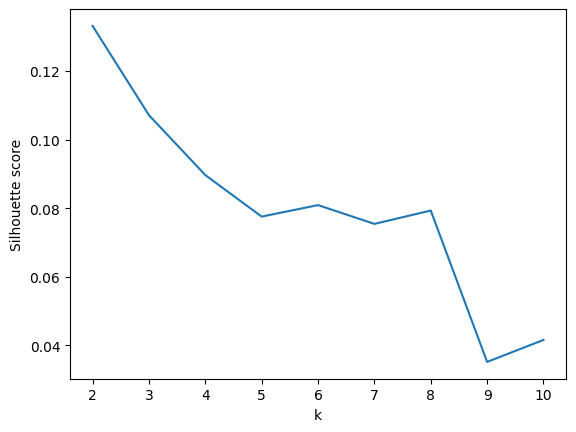

Best k: 2


In [ ]:
X_pca_95 = pca.fit_transform(X_flat)
find_best_k(X_pca_95)

The best k is 2. In order to increase the efficiency, the dimension of data is decreased to 2.

###B.

In [ ]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)
y_hat = kmeans_3.fit_predict(X_pca_95)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


In [ ]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(image_tensor_labels)

print(image_tensor_labels)
print(y_encoded)

cm = confusion_matrix(y_encoded, y_hat)

row_ind, col_ind = linear_sum_assignment(-cm)

new_pred = np.zeros_like(y_hat)
for i, j in zip(col_ind, row_ind):
    new_pred[y_hat == i] = j

new_pred

['I' 'I' 'S' 'S' 'I' 'S' 'S' 'I' 'I' 'M' 'I' 'M' 'M' 'S' 'M' 'M' 'M' 'I'
 'I' 'I' 'M' 'I' 'S' 'S' 'S' 'S' 'S' 'M' 'S' 'M' 'M' 'I' 'M' 'M' 'M' 'M'
 'S' 'I' 'I' 'M' 'S' 'I' 'M' 'I' 'I' 'I' 'I' 'M' 'M' 'S' 'M' 'M' 'S' 'I'
 'S' 'S' 'I' 'I' 'M' 'S' 'M' 'M' 'M' 'S' 'M' 'S' 'S' 'M' 'M' 'I' 'M' 'I'
 'I' 'M' 'I' 'S' 'I' 'I' 'S' 'I' 'M' 'M' 'M' 'I' 'I' 'S' 'M' 'S' 'M' 'M'
 'S' 'S' 'S' 'M' 'I' 'M' 'M' 'I' 'I' 'M' 'S' 'I' 'I' 'I' 'I' 'S' 'S' 'M'
 'S' 'S' 'S' 'S' 'S' 'I' 'I' 'I' 'M' 'I' 'M' 'I' 'I' 'M' 'I' 'I' 'I' 'S'
 'M' 'M' 'I' 'S' 'M' 'I' 'M' 'M' 'M' 'I' 'S' 'M' 'S' 'M' 'S' 'S' 'S' 'M'
 'M' 'S' 'M' 'S' 'M' 'S' 'S' 'I' 'M' 'M' 'M' 'I' 'I' 'S' 'M' 'M' 'S' 'I'
 'S' 'M' 'S' 'I' 'M' 'I' 'S' 'M' 'I' 'M' 'M' 'S' 'I' 'I' 'I' 'I' 'S' 'M'
 'S' 'S' 'I' 'I' 'S' 'I' 'S' 'I' 'I' 'S' 'S' 'S' 'S' 'M' 'I' 'I' 'I' 'M'
 'I' 'I' 'S' 'I' 'M' 'M' 'I' 'S' 'S' 'S' 'M' 'S' 'S' 'M' 'S' 'S' 'I' 'I'
 'S' 'S' 'I' 'S' 'I' 'S' 'M' 'M' 'I' 'I' 'M' 'I' 'M' 'S' 'S' 'M' 'S' 'S'
 'S' 'S' 'M' 'S' 'M' 'I' 'I' 'M' 'M' 'S' 'I' 'S' 'M

array([0, 2, 0, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 1, 0, 2, 0, 2, 2, 0, 0, 0,
       0, 2, 0, 2, 0, 0, 2, 2, 1, 0, 2, 1, 1, 0, 2, 0, 1, 2, 1, 0, 1, 2,
       2, 2, 2, 1, 1, 1, 2, 0, 2, 2, 0, 2, 1, 1, 1, 1, 2, 1, 2, 2, 1, 2,
       1, 2, 2, 2, 2, 1, 2, 1, 2, 0, 1, 2, 1, 2, 1, 2, 2, 2, 2, 0, 0, 2,
       1, 0, 0, 2, 2, 2, 1, 2, 0, 0, 1, 0, 2, 1, 1, 0, 2, 2, 1, 1, 0, 2,
       2, 2, 0, 0, 2, 2, 2, 0, 1, 0, 2, 2, 0, 1, 2, 1, 1, 2, 0, 0, 1, 1,
       2, 2, 0, 2, 2, 1, 1, 2, 1, 2, 0, 2, 1, 0, 1, 1, 2, 1, 2, 1, 1, 0,
       0, 2, 2, 2, 2, 0, 2, 0, 1, 0, 2, 1, 0, 2, 2, 1, 2, 1, 0, 0, 2, 0,
       1, 0, 1, 1, 2, 2, 0, 0, 2, 0, 2, 2, 0, 1, 1, 1, 2, 2, 0, 0, 2, 2,
       1, 1, 2, 2, 1, 1, 2, 2, 0, 2, 2, 1, 2, 2, 1, 1, 1, 2, 1, 0, 1, 1,
       0, 2, 2, 0, 2, 0, 2, 1, 0, 0, 0, 1, 2, 2, 1, 2, 2, 0, 1, 0, 1, 2,
       0, 0, 1, 1, 1, 2, 1, 1, 1, 0, 2, 2, 2, 2, 1, 0, 2, 0, 2, 0, 0, 1,
       1, 2, 2, 1, 1, 0, 1, 2, 0, 2, 0, 1, 0, 0, 2, 0, 1, 2, 0, 1, 0, 0,
       2, 2, 2, 0, 2, 0, 0, 2, 0, 0, 0, 2, 0, 1, 0,

In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_encoded, new_pred)
accuracy

0.39444444444444443

The accuracy is around 39.44%.

In [ ]:
confusion_matrix(y_encoded, new_pred)

array([[44, 32, 44],
       [33, 41, 46],
       [27, 36, 57]])

###C.

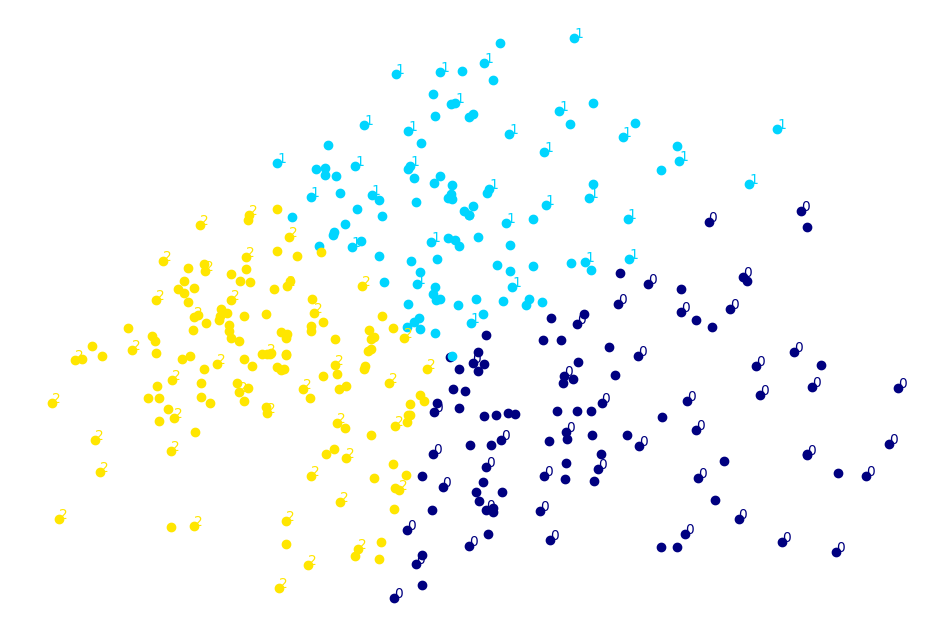

In [ ]:
pca_for_kmeans = PCA(n_components=2)
X_kmeans_pca = pca_for_kmeans.fit_transform(X_flat)

plot_digits(X_kmeans_pca, new_pred)

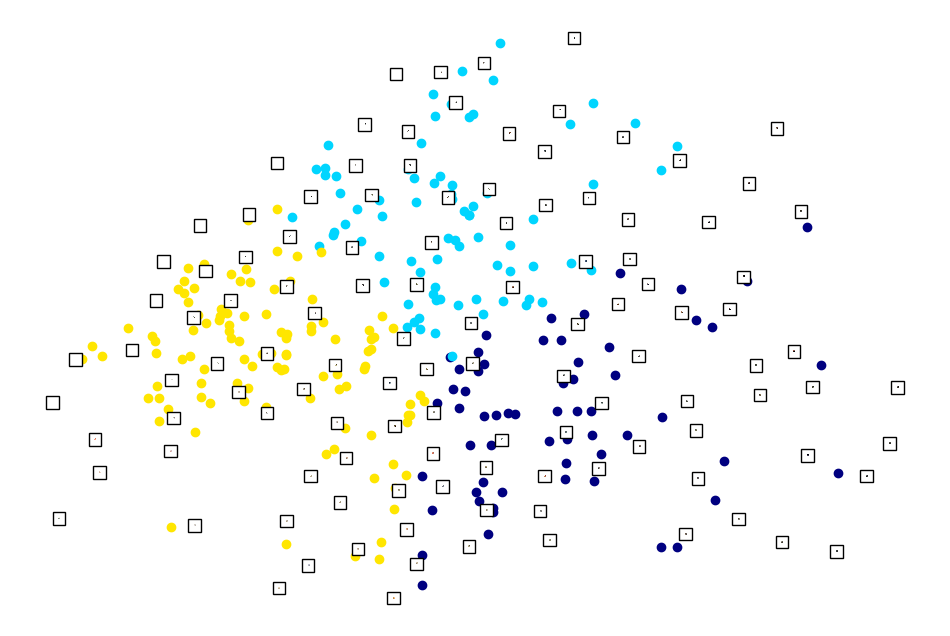

In [ ]:
plot_digits(X_kmeans_pca, new_pred, images=images_np)

#**5. EM**

###A.

In [ ]:
from sklearn.mixture import GaussianMixture

def EM_find_best_k(X, k_min=2, k_max=10, criterion='bic'):
    bic_scores = []
    aic_scores = []
    ks = list(range(k_min, k_max + 1))

    for k in ks:
        gmm = GaussianMixture(n_components=k, random_state=42, max_iter=200, tol=1e-3)
        gmm.fit(X)
        bic_scores.append(gmm.bic(X))
        aic_scores.append(gmm.aic(X))

    bic_scores = np.array(bic_scores)
    aic_scores = np.array(aic_scores)

    if criterion == 'bic':
        best_k = ks[np.argmin(bic_scores)]
        scores = bic_scores
        ylabel = 'BIC'
    elif criterion == 'aic':
        best_k = ks[np.argmin(aic_scores)]
        scores = aic_scores
        ylabel = 'AIC'
    else:
        raise ValueError("criterion must be 'bic' or 'aic'")

    # 绘图
    plt.figure(figsize=(8, 4))
    plt.plot(ks, scores, marker='o')
    plt.title(f'{ylabel} for different k values')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

    print(f'Best k according to {ylabel}: {best_k}')

Here we use different criteria to find the best k.

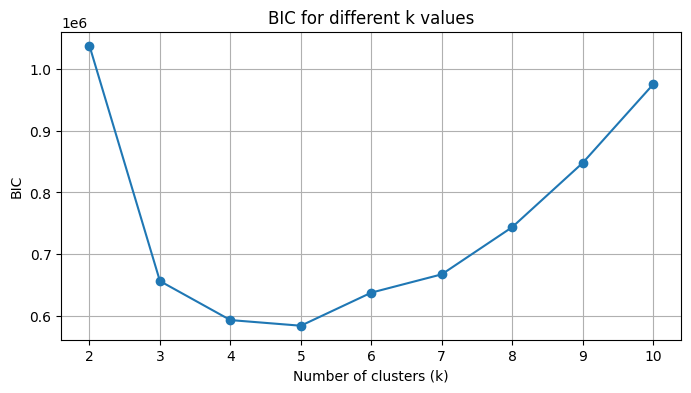

Best k according to BIC: 5


In [ ]:
X_em_95 = pca.fit_transform(X_flat)
EM_find_best_k(X_em_95, 2, 10)

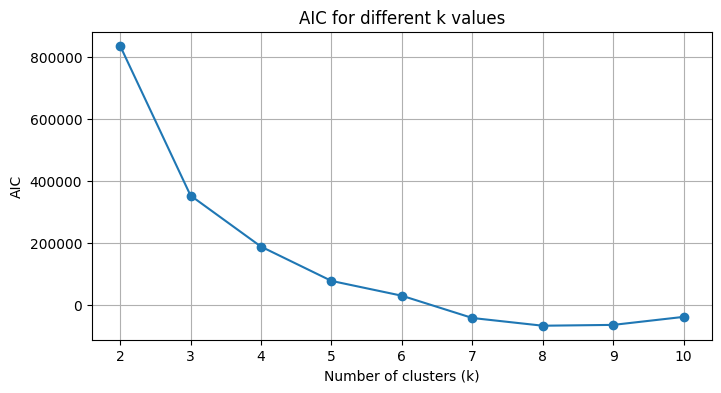

Best k according to AIC: 8


In [ ]:
EM_find_best_k(X_em_95, 2, 10, 'aic')

From BIC, the best k is 5; from AIC, the best k is 8.

###B. and C.
The clutering accuracy is around 38.05%. The confusion matrix and the scattering data are also below.

0.38055555555555554
[[48 31 41]
 [37 38 45]
 [33 36 51]]


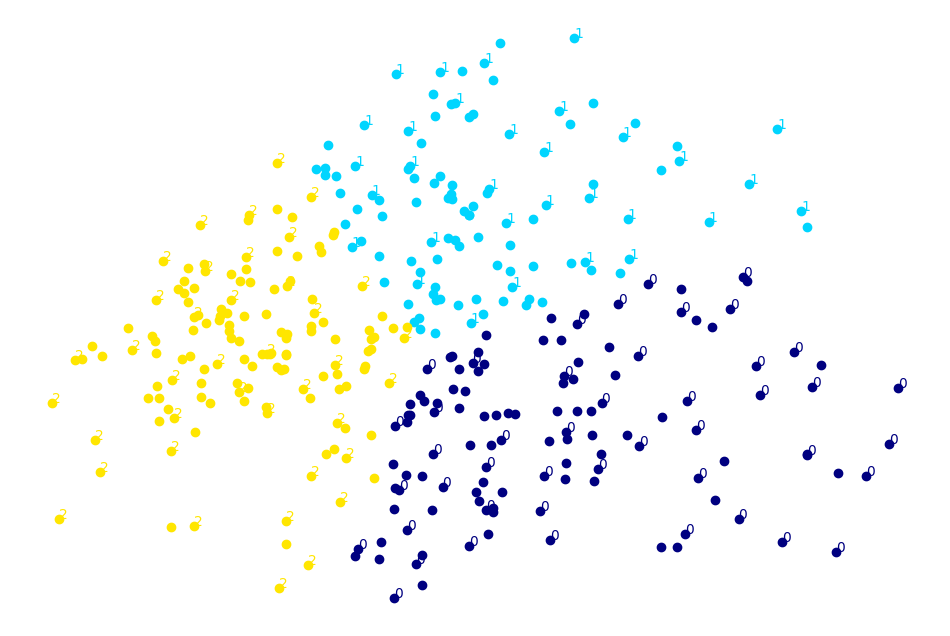

In [ ]:
em_3 = GaussianMixture(n_components=3, random_state=42, max_iter=200, tol=1e-3)
y_hat = em_3.fit_predict(X_em_95)

cm = confusion_matrix(y_encoded, y_hat)

row_ind, col_ind = linear_sum_assignment(-cm)

new_pred = np.zeros_like(y_hat)
for i, j in zip(col_ind, row_ind):
    new_pred[y_hat == i] = j

accuracy = accuracy_score(y_encoded, new_pred)
accuracy

print(accuracy)
print(confusion_matrix(y_encoded, new_pred))

pca_for_em = PCA(n_components=2)
X_em_pca = pca_for_em.fit_transform(X_flat)

plot_digits(X_em_pca, new_pred)

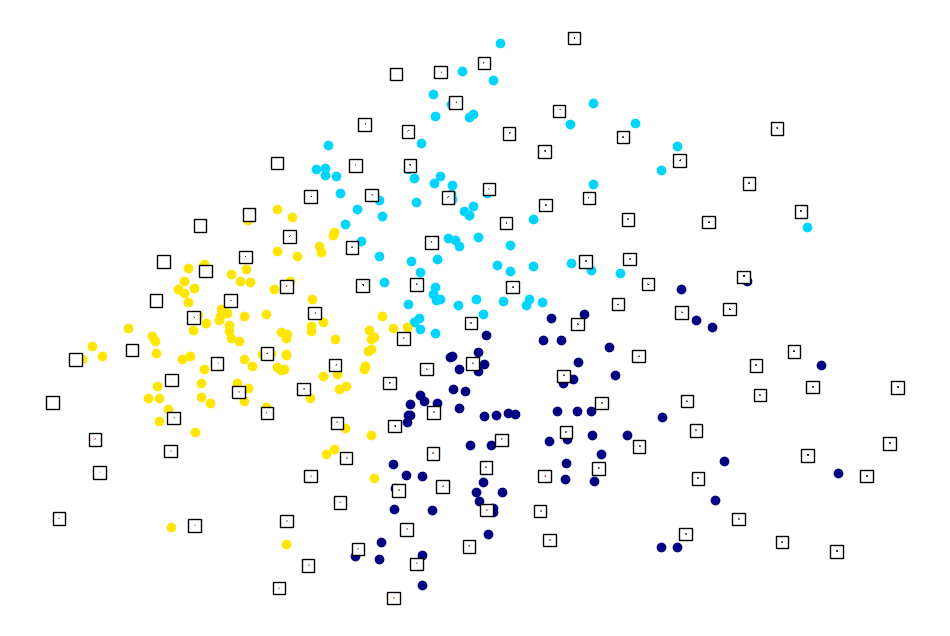

In [ ]:
plot_digits(X_em_pca, new_pred, images=images_np)

###D.

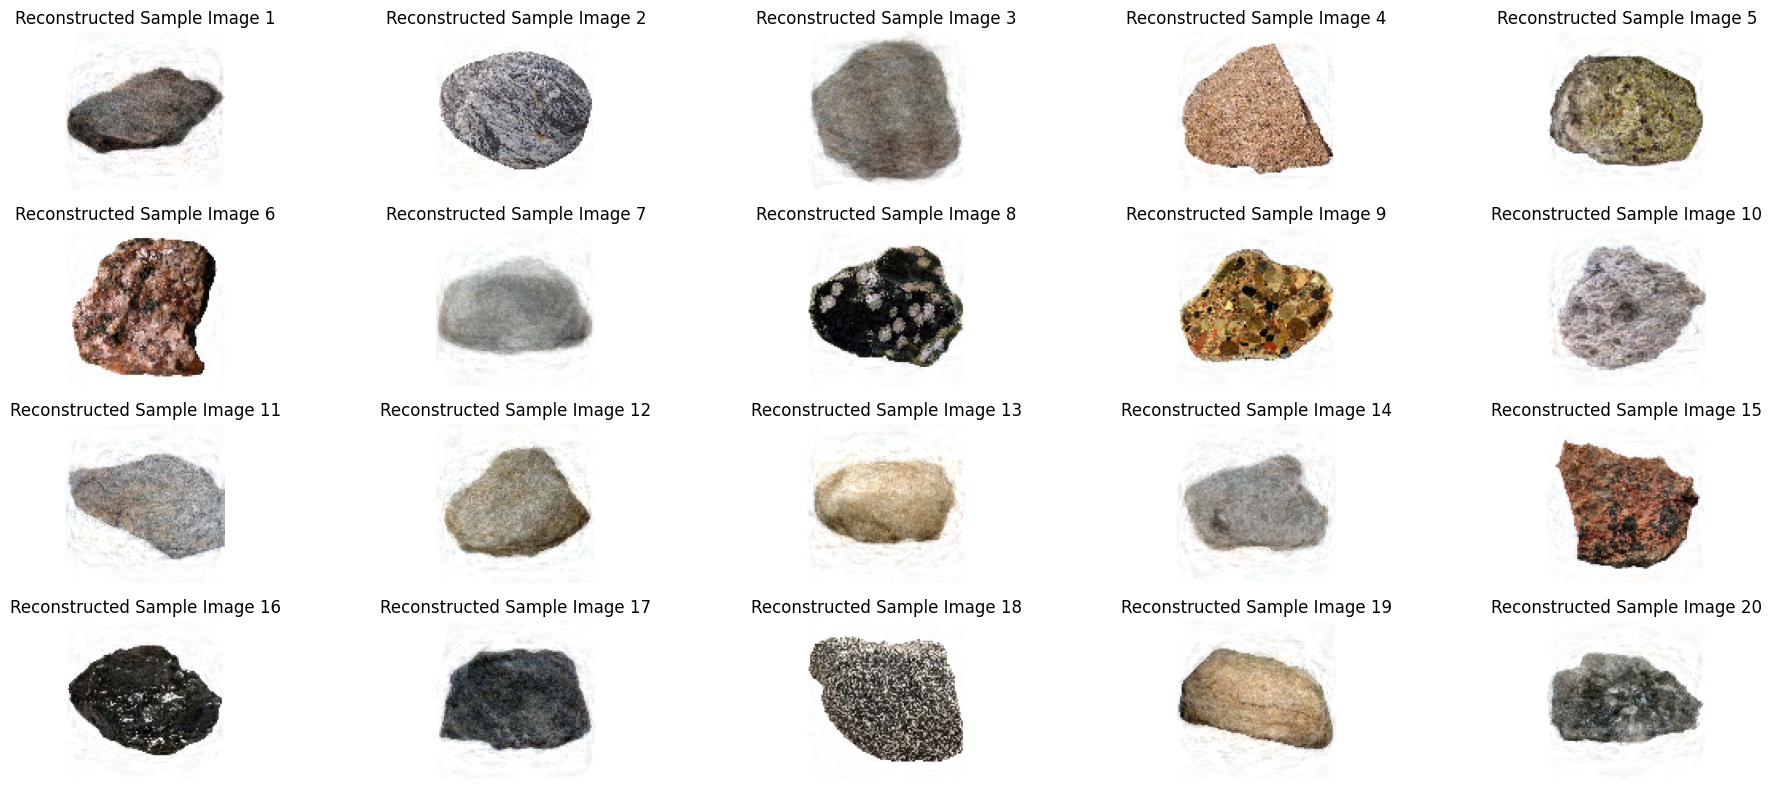

In [ ]:
import pandas as pd

X_df = pd.DataFrame(X_em_95)
X_df_sample = X_df.sample(n=20, random_state=42)

X_df_flat = pca.inverse_transform(X_df_sample)
X_np_flat = X_df_flat
sample_images = X_np_flat.reshape((-1, 100, 100, 3))
sample_images = np.clip(sample_images, 0, 255)

fig, axs = plt.subplots(4, 5, figsize=(20, 8))
for i, ax in enumerate(axs.flat):
    ax.imshow(sample_images[i].astype(np.uint8))
    ax.axis('off')
    ax.set_title(f"Reconstructed Sample Image {i + 1}")
plt.tight_layout()
plt.show()

#**6. NN**

###A.
The training time is 7114.6 milliseconds.

In [ ]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout

In [ ]:
NN_model = Sequential()
NN_model.add(keras.layers.Flatten(input_shape=[100, 100, 3]))
NN_model.add(keras.layers.Dense(250, activation='relu'))
NN_model.add(Dropout(0.5))
NN_model.add(keras.layers.Dense(100, activation='relu'))
NN_model.add(Dropout(0.5))
NN_model.add(keras.layers.Dense(3, activation='softmax'))
NN_model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 30000)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 250)                 │       7,500,250 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 250)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100)                 │          25,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,525,653 (28.71 MB)

 Trainable params: 7,525,653 (28.71 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
rocks_zip_2 = '120 Rocks/120 Rocks.zip'

# Unzipping
if os.path.exists(rocks_zip_2):
    extract_to = os.path.splitext(rocks_zip_2)[0]

    with zipfile.ZipFile(rocks_zip_2, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

    os.remove(rocks_zip_2)

else:
    print('File already extracted')

File already extracted


In [ ]:
val_image_path = glob.glob('/kaggle/input/hw03-q1/120 Rocks/120 Rocks/*.jpg')

val_images = [tf.keras.preprocessing.image.load_img(p, target_size=(100, 100)) for p in val_image_path]

zoomed_images = [tf.keras.preprocessing.image.load_img(p, target_size=(100, 100)) for p in image_path]
zoomed_image_tensor = tf.convert_to_tensor(np.array(zoomed_images), dtype=tf.float32)

val_image_tensor = tf.convert_to_tensor(np.array(val_images), dtype=tf.float32)

val_flat_images = val_image_tensor.numpy().reshape(val_image_tensor.shape[0], -1)
val_flat_images.shape

(120, 30000)

In [ ]:
image_tensor_labels = []
val_image_tensor_labels = []
X = []
X_val = []

for path in image_path:
    img = tf.keras.preprocessing.image.load_img(path, target_size=(100, 100))
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    zoomed_img_tensor = tf.convert_to_tensor(img_array, dtype=tf.float32) / 255.0

    X.append(zoomed_img_tensor)

    filename = os.path.basename(path)
    label = filename[0]
    image_tensor_labels.append(label)

for path in val_image_path:
    img = tf.keras.preprocessing.image.load_img(path, target_size=(100, 100))
    val_img_array = tf.keras.preprocessing.image.img_to_array(img)
    val_img_tensor = tf.convert_to_tensor(val_img_array, dtype=tf.float32) / 255.0

    X_val.append(val_img_tensor)

    filename = os.path.basename(path)
    label = filename[0]
    val_image_tensor_labels.append(label)

image_tensor_labels = np.array(image_tensor_labels)
val_image_tensor_labels = np.array(val_image_tensor_labels)
X = np.array(X)
X_val = np.array(X_val)


In [ ]:

import tensorflow as tf
len(tf.config.list_physical_devices('GPU'))

2

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import time

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(image_tensor_labels)
y_val_encoded = encoder.transform(val_image_tensor_labels)

NN_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

start_time = time.time()
history = NN_model.fit(
    X, y_train_encoded,
    validation_data=(X_val, y_val_encoded),
    epochs=100,
    batch_size=5,
    callbacks=[early_stop],
    verbose=1
)
end_time = time.time()
print(f"Training time: {end_time - start_time:.4f} sec.")

Epoch 1/100


I0000 00:00:1745010013.988881      85 service.cc:148] XLA service 0x7f3744005480 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745010013.989686      85 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1745010013.989711      85 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1745010014.214455      85 cuda_dnn.cc:529] Loaded cuDNN version 90300


54/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2974 - loss: 43.8167

I0000 00:00:1745010015.993541      85 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


72/72 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3005 - loss: 41.9982 - val_accuracy: 0.3417 - val_loss: 1.7296
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2577 - loss: 2.8929 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3605 - loss: 1.2769 - val_accuracy: 0.3333 - val_loss: 1.0988
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3311 - loss: 1.0992 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3438 - loss: 1.0989 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3659 - loss: 1.0984 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3593 - loss: 1.0984 - val_accuracy: 0.3333 - val_loss: 1.0987
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2591 - loss: 1.0992 - val_accuracy: 0.3333 - val_loss: 1

###B.

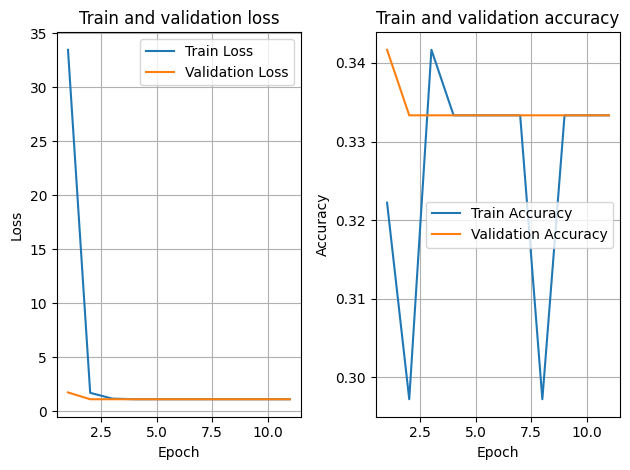

In [ ]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Train and validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Train Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Train and validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

###C.

The network has 7,525,653 parameters, with 353 bias parameters.

###D.

In [ ]:
from tensorflow.keras.models import Model

def extract_activations(model, layer, input_data, reduce_dim=2, flatten=True):
    intermediate = Model(inputs=model.input,
                         outputs=model.get_layer(layer).output)

    activations = intermediate.predict(input_data)

    if flatten:
        activations = activations.reshape((activations.shape[0], -1))

    if reduce_dim is not None:
        pca = PCA(n_components=reduce_dim, random_state=42)
        activations = pca.fit_transform(activations)

    return activations

In [ ]:
def activation_EM(activations, true_labels, max_clusters=10, N=3, title_suffix=''):
    BICs, AICs = [], []
    for n in range(1, max_clusters+1):
        em = GaussianMixture(n_components=n, random_state=42)
        em.fit(activations)
        BICs.append(em.bic(activations))
        AICs.append(em.aic(activations))

    plt.figure(figsize=(16, 9))
    plt.plot(range(1, max_clusters + 1), BICs, label='BIC')
    plt.plot(range(1, max_clusters + 1), AICs, label='AIC')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Score')
    plt.title(f'BIC/AIC for cluster {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()

    em_fixed = GaussianMixture(n_components=N, random_state=42)
    cluster_labels = em_fixed.fit_predict(activations)

    def match_labels(y_true, y_pred):
        D = max(y_pred.max(), y_true.max()) + 1
        cost_matrix = np.zeros((D, D), dtype=np.int64)
        for i in range(len(y_true)):
            cost_matrix[y_pred[i], y_true[i]] += 1
        row_ind, col_ind = linear_sum_assignment(-cost_matrix)  # maximize accuracy
        mapping = {row: col for row, col in zip(row_ind, col_ind)}
        matched = np.array([mapping[label] for label in y_pred])
        return matched

    matched_labels = match_labels(true_labels, cluster_labels)

    acc = accuracy_score(true_labels, matched_labels)
    cm = confusion_matrix(true_labels, matched_labels)

    print(f"EM clustering accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    reduced = activations

    plt.figure(figsize=(4, 3))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=cluster_labels, cmap='viridis', s=15)
    plt.title(f'EM (n={N}) {title_suffix}')
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.colorbar(label='Cluster ID')
    plt.grid(True)
    plt.show()

In [ ]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Flatten, Dense

inputs = Input(shape=(100, 100, 3))
x = Dense(250, activation='relu', name='dense_1')(inputs)
x = Dense(100, activation='relu', name='dense_2')(x)
outputs = Dense(3, activation='softmax')(x)

NN_model = Model(inputs=inputs, outputs=outputs)
NN_model.summary()



Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100, 100, 250)       │           1,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 100, 100, 100)       │          25,100 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 100, 100, 3)         │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 26,403 (103.14 KB)

 Trainable params: 26,403 (103.14 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


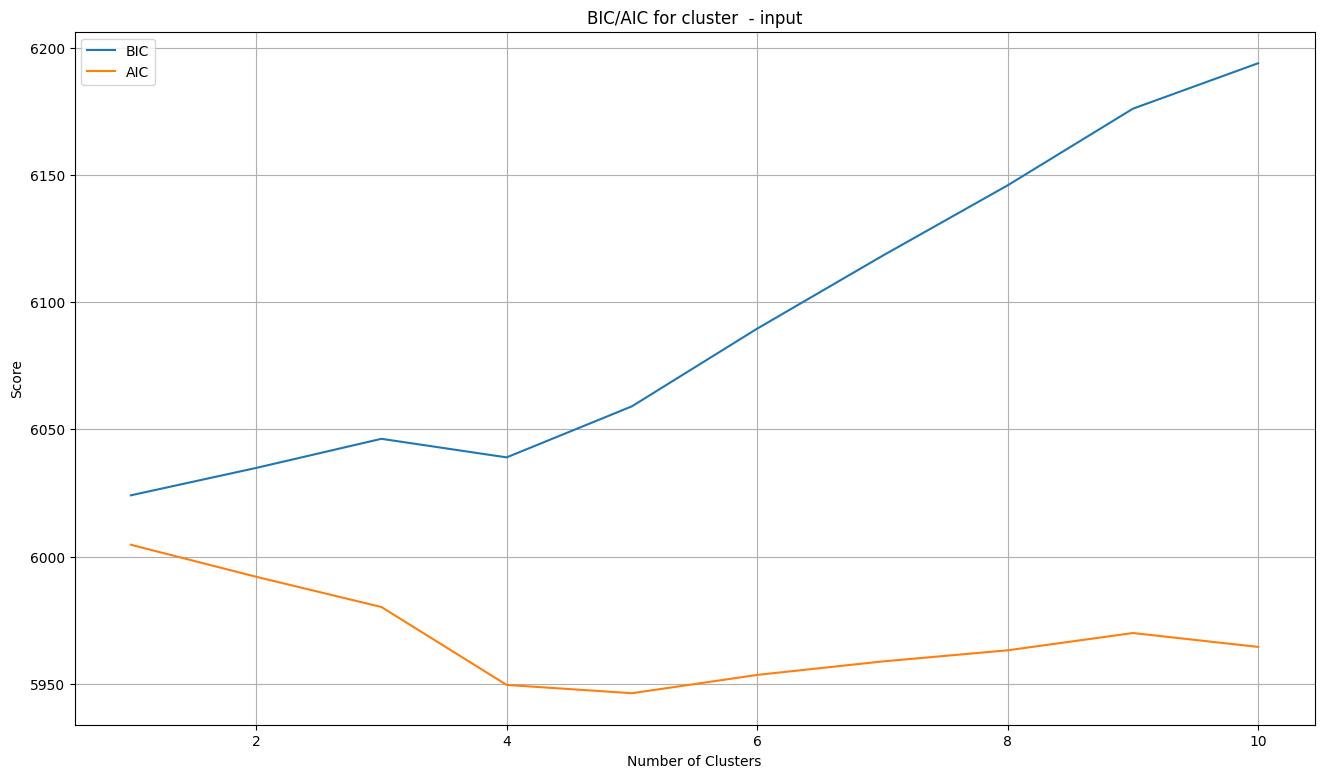

EM clustering accuracy: 0.4056
Confusion Matrix:
[[43 34 43]
 [32 41 47]
 [28 30 62]]


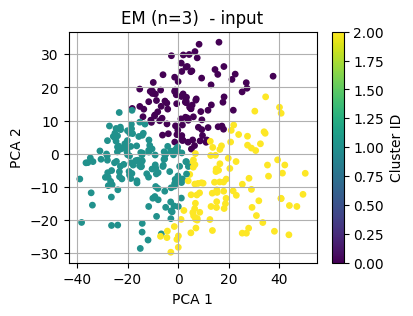

In [ ]:
NN_model.predict(X[:1])

input_dense = extract_activations(NN_model, NN_model.layers[0].name, X)
activation_EM(input_dense, true_labels=y_train_encoded, title_suffix=" - input")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


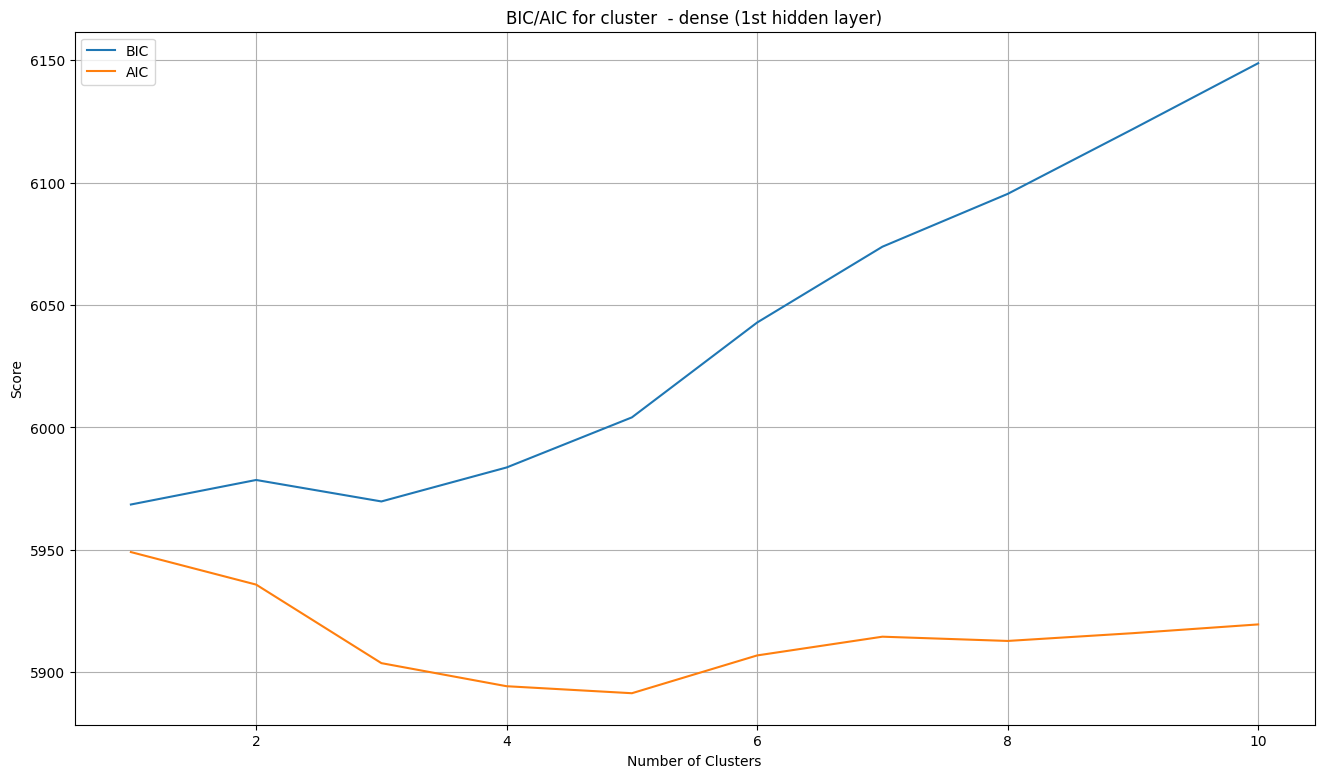

EM clustering accuracy: 0.3833
Confusion Matrix:
[[53 34 33]
 [42 40 38]
 [44 31 45]]


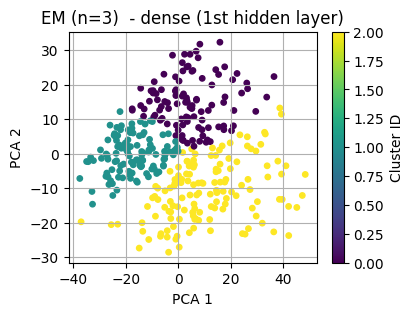

In [ ]:
first_dense = extract_activations(NN_model, NN_model.layers[1].name, X)
activation_EM(first_dense, true_labels=y_train_encoded, title_suffix=" - dense (1st hidden layer)")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


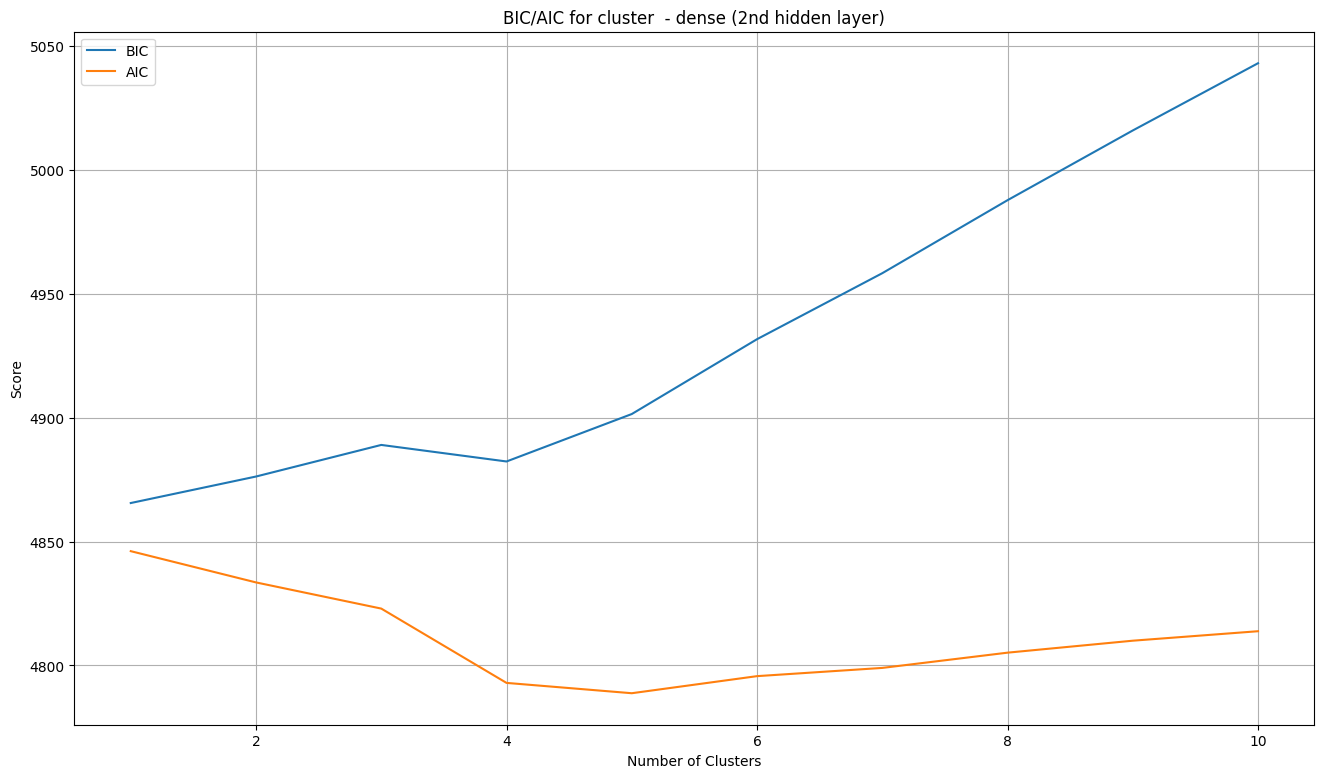

EM clustering accuracy: 0.3944
Confusion Matrix:
[[42 34 44]
 [30 39 51]
 [28 31 61]]


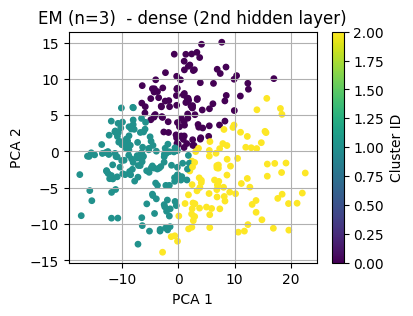

In [ ]:
second_dense = extract_activations(NN_model, NN_model.layers[2].name, X)
activation_EM(second_dense,true_labels=y_train_encoded,  title_suffix=" - dense (2nd hidden layer)")

Due to the scattered distribution of the whole dataset, there are small changes in Cluster #1 throughout the whole training process.